In [1]:
# ============================================
# PUBLIC HEALTH SURVEILLANCE DATA ANALYSIS
# ============================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Display settings
pd.set_option("display.max_columns", None)

# Seaborn style
sns.set_theme(style="whitegrid")

df = pd.read_csv(
    r"C:\Users\User\Documents\Khingfm_projects\data_science\assets\personal_datasets\public_health_surveillance_dataset (1).csv"
)

print(df.head())
print(df.tail())



   Age  Gender Location   Ethnicity  SES  Chronic_Conditions  \
0   51    Male    Urban  Ethnicity3  Low                   0   
1   92    Male    Urban  Ethnicity2  Low                   1   
2   14    Male    Urban  Ethnicity3  Low                   0   
3   71  Female    Urban  Ethnicity2  Low                   0   
4   60  Female    Urban  Ethnicity1  Low                   0   

   Vaccination_Status Medical_History Immunity_Level Reported_Symptoms  \
0                   0             NaN         Medium              Mild   
1                   0             NaN         Medium            Severe   
2                   1             NaN            Low               NaN   
3                   0             NaN         Medium          Moderate   
4                   0             NaN            Low              Mild   

  Diagnosis Testing_Results Date_of_Onset  Temperature  AQI   Humidity  \
0       NaN        Negative    2023-04-05    29.312280  133  31.512868   
1       NaN        Neg

In [2]:
print(df.shape)

(43689, 35)


In [3]:
print(df.columns)
print(df.dtypes)

Index(['Age', 'Gender', 'Location', 'Ethnicity', 'SES', 'Chronic_Conditions',
       'Vaccination_Status', 'Medical_History', 'Immunity_Level',
       'Reported_Symptoms', 'Diagnosis', 'Testing_Results', 'Date_of_Onset',
       'Temperature', 'AQI', 'Humidity', 'Population_Density',
       'Travel_History', 'Social_Activity',
       'Compliance_with_Health_Guidelines', 'Vaccination_Hesitancy',
       'Transmission_Rate', 'Mortality_Rate', 'Case_Fatality_Ratio',
       'Hospitalization_Rate', 'Hospital_Capacity',
       'Healthcare_Personnel_Availability', 'Resource_Utilization',
       'Date_of_Data_Collection', 'Daily_New_Cases',
       'Vaccination_Campaign_Dates', 'Outbreak_Status', 'Infection_Risk_Level',
       'Disease_Severity', 'Hospitalization_Requirement'],
      dtype='str')
Age                                    int64
Gender                                   str
Location                                 str
Ethnicity                                str
SES                    

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43689 entries, 0 to 43688
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                43689 non-null  int64  
 1   Gender                             43689 non-null  str    
 2   Location                           43689 non-null  str    
 3   Ethnicity                          43689 non-null  str    
 4   SES                                43689 non-null  str    
 5   Chronic_Conditions                 43689 non-null  int64  
 6   Vaccination_Status                 43689 non-null  int64  
 7   Medical_History                    17430 non-null  str    
 8   Immunity_Level                     43689 non-null  str    
 9   Reported_Symptoms                  21837 non-null  str    
 10  Diagnosis                          13050 non-null  str    
 11  Testing_Results                    43689 non-null  str    
 12  D

In [5]:
print(df.describe())

                Age  Chronic_Conditions  Vaccination_Status   Temperature  \
count  43689.000000        43689.000000        43689.000000  43689.000000   
mean      49.941335            0.299984            0.200897     29.939132   
std       29.161997            0.458256            0.400676     10.003867   
min        0.000000            0.000000            0.000000    -13.587863   
25%       25.000000            0.000000            0.000000     23.132805   
50%       50.000000            0.000000            0.000000     29.963278   
75%       75.000000            1.000000            0.000000     36.658827   
max      100.000000            1.000000            1.000000     74.994492   

                AQI      Humidity  Compliance_with_Health_Guidelines  \
count  43689.000000  43689.000000                       43689.000000   
mean      74.843164     49.871732                           0.700886   
std       66.481341     23.037879                           0.457875   
min        0.00000

In [6]:
print(df.describe(include="all"))

                 Age Gender Location   Ethnicity    SES  Chronic_Conditions  \
count   43689.000000  43689    43689       43689  43689        43689.000000   
unique           NaN      3        3           4      3                 NaN   
top              NaN   Male    Urban  Ethnicity1    Low                 NaN   
freq             NaN  24032    30557       21783  26124                 NaN   
mean       49.941335    NaN      NaN         NaN    NaN            0.299984   
std        29.161997    NaN      NaN         NaN    NaN            0.458256   
min         0.000000    NaN      NaN         NaN    NaN            0.000000   
25%        25.000000    NaN      NaN         NaN    NaN            0.000000   
50%        50.000000    NaN      NaN         NaN    NaN            0.000000   
75%        75.000000    NaN      NaN         NaN    NaN            1.000000   
max       100.000000    NaN      NaN         NaN    NaN            1.000000   

        Vaccination_Status Medical_History Immunity

In [7]:
missing_values = df.isnull().sum()

print(missing_values)

Age                                      0
Gender                                   0
Location                                 0
Ethnicity                                0
SES                                      0
Chronic_Conditions                       0
Vaccination_Status                       0
Medical_History                      26259
Immunity_Level                           0
Reported_Symptoms                    21852
Diagnosis                            30639
Testing_Results                          0
Date_of_Onset                            0
Temperature                              0
AQI                                      0
Humidity                                 0
Population_Density                       0
Travel_History                           0
Social_Activity                          0
Compliance_with_Health_Guidelines        0
Vaccination_Hesitancy                    0
Transmission_Rate                        0
Mortality_Rate                           0
Case_Fatali

In [8]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

print(missing_percentage.sort_values(ascending=False))

Diagnosis                            70.129781
Medical_History                      60.104374
Reported_Symptoms                    50.017167
Location                              0.000000
Gender                                0.000000
Age                                   0.000000
Ethnicity                             0.000000
Vaccination_Status                    0.000000
Chronic_Conditions                    0.000000
SES                                   0.000000
Immunity_Level                        0.000000
Testing_Results                       0.000000
Date_of_Onset                         0.000000
Temperature                           0.000000
AQI                                   0.000000
Humidity                              0.000000
Population_Density                    0.000000
Travel_History                        0.000000
Social_Activity                       0.000000
Compliance_with_Health_Guidelines     0.000000
Vaccination_Hesitancy                 0.000000
Transmission_

In [9]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


In [10]:
print(df["Gender"].value_counts())

Gender
Male      24032
Female    17562
Other      2095
Name: count, dtype: int64


In [11]:
print(df["Location"].value_counts())

Location
Urban       30557
Rural        8846
Suburban     4286
Name: count, dtype: int64


In [12]:
print(df["Disease_Severity"].value_counts())

Disease_Severity
Mild        30502
Moderate     8791
Severe       4396
Name: count, dtype: int64


In [14]:
print(df["Infection_Risk_Level"].value_counts())

Infection_Risk_Level
Low Risk       26346
Medium Risk    12912
High Risk       4431
Name: count, dtype: int64


In [15]:
print(df["Outbreak_Status"].value_counts())

Outbreak_Status
No Outbreak          30482
Emerging Outbreak     8811
Ongoing Outbreak      4396
Name: count, dtype: int64


In [16]:
infection_risk = (
    df["Infection_Risk_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(infection_risk)

Infection_Risk_Level
Low Risk       60.30
Medium Risk    29.55
High Risk      10.14
Name: proportion, dtype: float64


In [20]:
# Check for outliers in the Age column
plt.figure(figsize=(10, 6))
print("Mean age:", df["Age"].mean())
print("Median age:", df["Age"].median())
print("Minimum age:", df["Age"].min())
print("Maximum age:", df["Age"].max())

Mean age: 49.94133534757032
Median age: 50.0
Minimum age: 0
Maximum age: 100


<Figure size 1000x600 with 0 Axes>

In [21]:
# Check for outliers in the Age column using a boxplot
print("Mean:", np.mean(df["Age"]))
print("Median:", np.median(df["Age"]))
print("Standard deviation:", np.std(df["Age"]))

Mean: 49.94133534757032
Median: 50.0
Standard deviation: 29.161662974461883


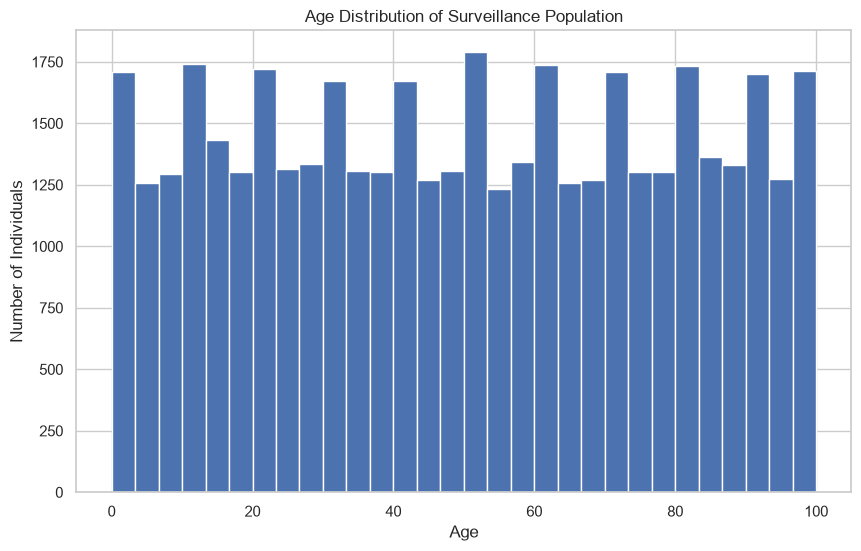

In [23]:
# Age Distribution Chart
plt.figure(figsize=(10, 6))

plt.hist(
    df["Age"],
    bins=30
)

plt.title("Age Distribution of Surveillance Population")
plt.xlabel("Age")
plt.ylabel("Number of Individuals")

plt.show()

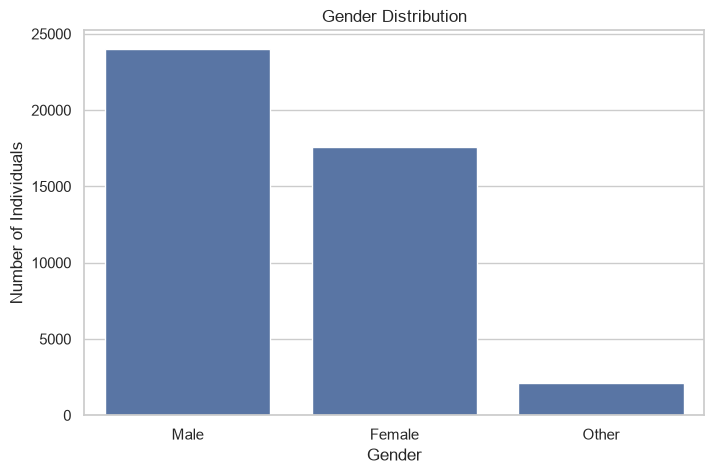

In [24]:
# Gender distribution chart
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Individuals")

plt.show()